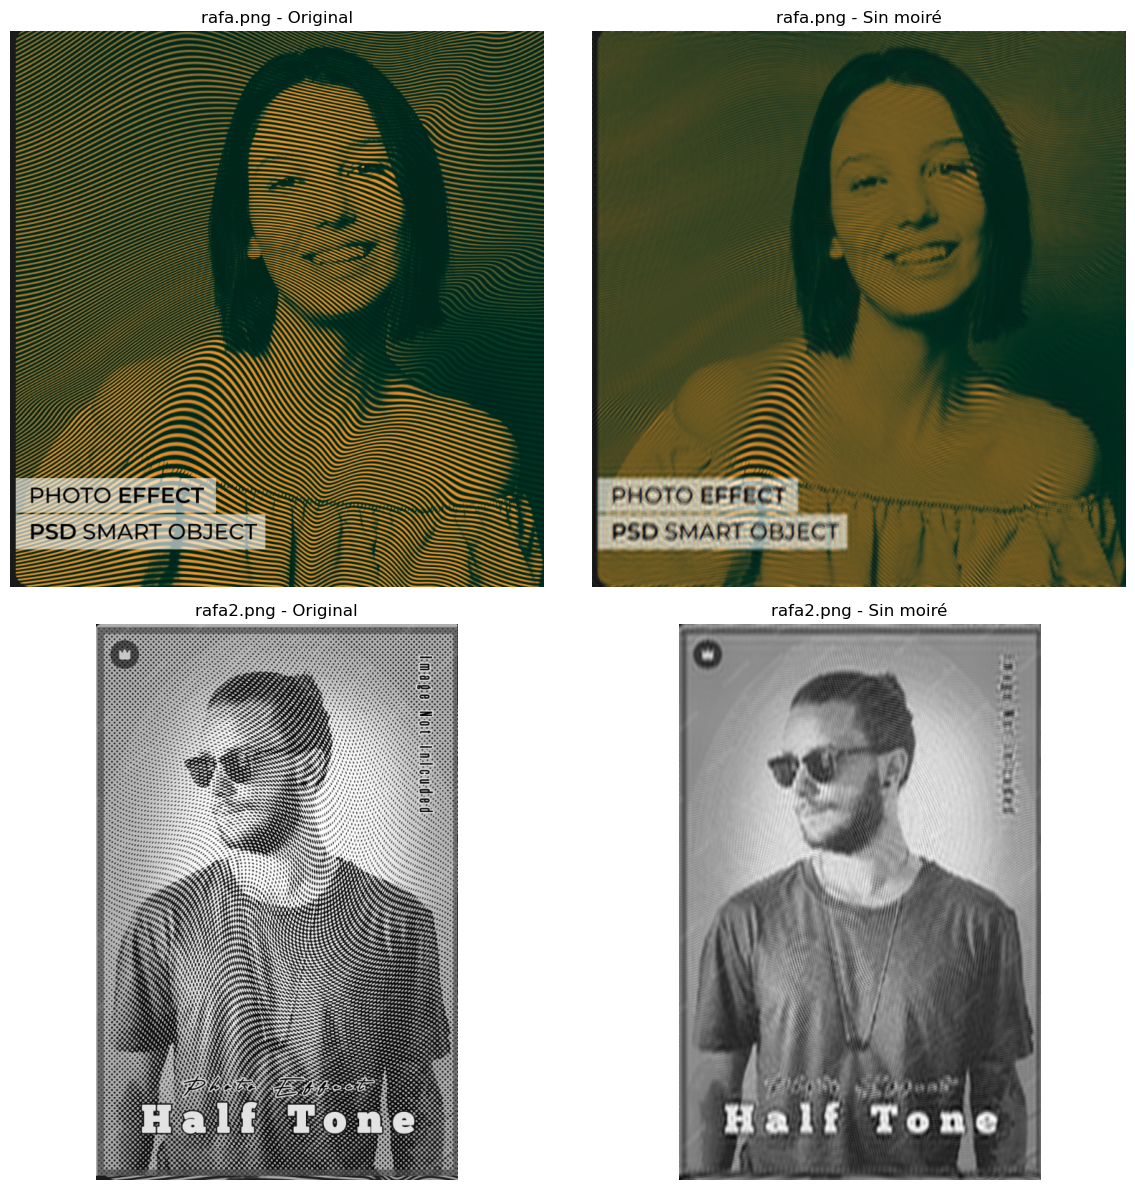

Guardadas: rafa_sin_moire.png y rafa2_sin_moire.png


In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def eliminar_moire_fft(imagen, umbral_factor=3.5, radio_notch=8, suavizado_final=3):
    img_float = imagen.astype(np.float32)
    fft = np.fft.fft2(img_float)
    fft_shift = np.fft.fftshift(fft)
    magnitud = np.abs(fft_shift)
    rows, cols = imagen.shape
    crow, ccol = rows // 2, cols // 2
    mascara_centro = np.zeros(imagen.shape, np.uint8)
    cv2.circle(mascara_centro, (ccol, crow), min(rows, cols) // 8, 1, -1)
    magnitud_sin_centro = magnitud * (1 - mascara_centro)
    media = np.mean(magnitud_sin_centro[magnitud_sin_centro > 0])
    std = np.std(magnitud_sin_centro[magnitud_sin_centro > 0])
    umbral = media + umbral_factor * std
    filtro = np.ones(imagen.shape, np.float32)
    picos = (magnitud_sin_centro > umbral)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (radio_notch*2, radio_notch*2))
    picos_dilatados = cv2.dilate(picos.astype(np.uint8), kernel)
    filtro[picos_dilatados == 1] = 0
    filtro = cv2.GaussianBlur(filtro, (21, 21), 5)
    fft_filtrado = fft_shift * filtro
    img_rec = np.abs(np.fft.ifft2(np.fft.ifftshift(fft_filtrado)))
    img_rec = np.clip(img_rec, 0, 255).astype(np.uint8)
    if suavizado_final > 1:
        img_rec = cv2.GaussianBlur(img_rec, (suavizado_final, suavizado_final), 0)
    return img_rec

def procesar_color(path, nombre_salida, umbral_factor=3.5, radio_notch=8, suavizado_final=3):
    img_bgr = cv2.imread(path)
    canales = cv2.split(img_bgr)
    canales_limpios = [eliminar_moire_fft(c, umbral_factor, radio_notch, suavizado_final) for c in canales]
    img_limpia = cv2.merge(canales_limpios)
    cv2.imwrite(nombre_salida, img_limpia)
    img_original_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_limpia_rgb = cv2.cvtColor(img_limpia, cv2.COLOR_BGR2RGB)
    return img_original_rgb, img_limpia_rgb

def procesar_gris(path, nombre_salida, umbral_factor=3.5, radio_notch=8, suavizado_final=3):
    img = cv2.imread(path, 0)
    img_limpia = eliminar_moire_fft(img, umbral_factor, radio_notch, suavizado_final)
    cv2.imwrite(nombre_salida, img_limpia)
    return img, img_limpia

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

orig1, limpia1 = procesar_color("rafa.png", "rafa_sin_moire.png", umbral_factor=3.0, radio_notch=10)
axes[0, 0].imshow(orig1)
axes[0, 0].set_title("rafa.png - Original")
axes[0, 0].axis('off')
axes[0, 1].imshow(limpia1)
axes[0, 1].set_title("rafa.png - Sin moiré")
axes[0, 1].axis('off')

orig2, limpia2 = procesar_gris("rafa2.png", "rafa2_sin_moire.png", umbral_factor=3.0, radio_notch=10)
axes[1, 0].imshow(orig2, cmap='gray')
axes[1, 0].set_title("rafa2.png - Original")
axes[1, 0].axis('off')
axes[1, 1].imshow(limpia2, cmap='gray')
axes[1, 1].set_title("rafa2.png - Sin moiré")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print("Guardadas: rafa_sin_moire.png y rafa2_sin_moire.png")

ALIASING

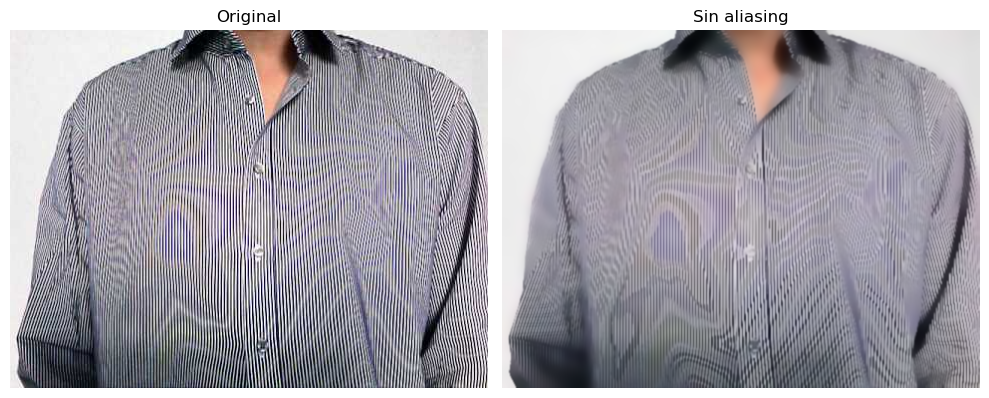

True

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread("rafa3.jpg")
img_fin = cv2.bilateralFilter(img, 15, 120, 120)
img_fin = cv2.bilateralFilter(img_fin, 15, 120, 120)  # dos pasadas
img_fin = cv2.GaussianBlur(img_fin, (3, 3), 0.8)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(img_fin, cv2.COLOR_BGR2RGB))
plt.title("Sin aliasing")
plt.axis('off')
plt.tight_layout()
plt.show()

cv2.imwrite("rafa3_limpia.jpg", img_fin)